# 📘 Análise de Dados - Indicadores de Pessoas Ocupadas e Desocupadas (2025)

Roger da Silva Ferreira  
Storytelling com Dados  
   

---

Este notebook apresenta uma análise detalhada dos indicadores de pessoas ocupadas e desocupadas no Brasil ao longo dos trimestres de 2025. Inclui:
- Limpeza e transformação dos dados  
- Tabelas e estatísticas descritivas  
- Construção de gráficos (Matplotlib / Plotly)  
- Rankings e comparações  
- Dashboard interativo  
- Interpretações dos resultados  

---


## 🔧 Como executar o Dashboard Interativo

Para visualizar o dashboard dinâmico, execute a célula abaixo.

O notebook usa **JupyterDash**, que permite exibir o painel diretamente no Jupyter Notebook.

Caso o dashboard não abra:
1. Reinicie o kernel  
2. Execute todas as células acima  
3. Execute novamente a célula do dashboard


# 🔹 Introdução à Análise da Desocupação Regional no Brasil

A análise da desocupação é fundamental para compreender a dinâmica do mercado de trabalho e identificar diferenças estruturais entre as regiões do país. Este estudo utiliza dados referentes ao ano de 2025 para investigar como a desocupação se distribui regionalmente, suas oscilações ao longo dos trimestres e quais padrões podem ser observados a partir das visualizações desenvolvidas. Por meio de gráficos comparativos e um dashboard interativo, o objetivo é oferecer uma visão clara, acessível e exploratória do comportamento da desocupação no Brasil, destacando tendências e possíveis interpretações para apoiar análises mais profundas.


# Importação de Bibliotecas

Nesta célula, importamos todas as bibliotecas necessárias para análise e visualização de dados, além de configurar algumas opções de exibição para melhor legibilidade.


In [1]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


In [2]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 📥 Carregamento e Exploração Inicial do Dataset


In [3]:
import pandas as pd

df = pd.read_csv("pnad_final.csv")

print("✔ Dataset carregado com sucesso!")
display(df.head())

✔ Dataset carregado com sucesso!


,UF,Trimestre,Total_Pessoas,Ordem
0,Brasil,T1_2025,173761,1
1,Rondônia,T1_2025,1397,1
2,Acre,T1_2025,654,1
3,Amazonas,T1_2025,3202,1
4,Roraima,T1_2025,480,1


In [4]:

print("🔧 Reconstruindo coluna 'Região'...")

mapa_regioes = {
    'Acre': 'Norte', 'Amapá': 'Norte', 'Amazonas': 'Norte', 'Pará': 'Norte',
    'Rondônia': 'Norte', 'Roraima': 'Norte', 'Tocantins': 'Norte',

    'Alagoas': 'Nordeste', 'Bahia': 'Nordeste', 'Ceará': 'Nordeste',
    'Maranhão': 'Nordeste', 'Paraíba': 'Nordeste', 'Pernambuco': 'Nordeste',
    'Piauí': 'Nordeste', 'Rio Grande do Norte': 'Nordeste', 'Sergipe': 'Nordeste',

    'Espírito Santo': 'Sudeste', 'Minas Gerais': 'Sudeste',
    'Rio de Janeiro': 'Sudeste', 'São Paulo': 'Sudeste',

    'Paraná': 'Sul', 'Rio Grande do Sul': 'Sul', 'Santa Catarina': 'Sul',

    'Distrito Federal': 'Centro-Oeste', 'Goiás': 'Centro-Oeste',
    'Mato Grosso': 'Centro-Oeste', 'Mato Grosso do Sul': 'Centro-Oeste'
}

if "UF" not in df.columns:
    raise KeyError("Coluna 'UF' não encontrada no dataset.")

df["Região"] = df["UF"].map(mapa_regioes)

if df["Região"].isna().any():
    print("⚠️ Atenção: existem UFs sem mapeamento de região.")

print("✔ Coluna 'Região' recriada com sucesso!\n")
display(df.head())


🔧 Reconstruindo coluna 'Região'...
⚠️ Atenção: existem UFs sem mapeamento de região.
✔ Coluna 'Região' recriada com sucesso!



,UF,Trimestre,Total_Pessoas,Ordem,Região
0,Brasil,T1_2025,173761,1,NaN
1,Rondônia,T1_2025,1397,1,Norte
2,Acre,T1_2025,654,1,Norte
3,Amazonas,T1_2025,3202,1,Norte
4,Roraima,T1_2025,480,1,Norte


## 🗺️ Classificação das Unidades Federativas por Região


In [5]:
print("🗺️ Distribuição por Região (sem Brasil):")
df_sem_brasil = df[df['UF'] != 'Brasil']
print(df_sem_brasil['Região'].value_counts())

print("\n📊 Total de registros por categoria:")
print(f"Total de registros: {len(df)}")
print(f"Registros de estados: {len(df_sem_brasil)}")
print(f"Registros do Brasil: {len(df) - len(df_sem_brasil)}")

print("\n📋 Amostra do dataset corrigido:")
display(df[['UF', 'Região', 'Trimestre', 'Total_Pessoas']].head(15))


🗺️ Distribuição por Região (sem Brasil):
Região
Nordeste        27
Norte           21
Sudeste         12
Centro-Oeste    12
Sul              9
Name: count, dtype: int64

📊 Total de registros por categoria:
Total de registros: 84
Registros de estados: 81
Registros do Brasil: 3

📋 Amostra do dataset corrigido:


,UF,Região,Trimestre,Total_Pessoas
0,Brasil,NaN,T1_2025,173761
1,Rondônia,Norte,T1_2025,1397
2,Acre,Norte,T1_2025,654
3,Amazonas,Norte,T1_2025,3202
4,Roraima,Norte,T1_2025,480
5,Pará,Norte,T1_2025,6743
6,Amapá,Norte,T1_2025,605
7,Tocantins,Norte,T1_2025,1252
8,Maranhão,Nordeste,T1_2025,5442
9,Piauí,Nordeste,T1_2025,2705


### 📈 Gráfico 1 — Evolução Trimestral do Emprego no Brasil

Este bloco gera um gráfico de linha mostrando a **evolução do total de pessoas ocupadas no Brasil ao longo dos três trimestres de 2025**.  
A análise utiliza apenas o registro nacional ("Brasil"), garantindo que a tendência reflita o comportamento agregado do país.

O gráfico apresenta:
- Ordenação correta dos trimestres (T1 → T3)
- Marcadores e rótulos dos valores
- Destaque visual da curva de crescimento
- Impressão dos valores numéricos e cálculo do crescimento total no período


📈 GRÁFICO 1: Evolução do Emprego no Brasil


C:\Users\roger\AppData\Local\Temp\ipykernel_32008\2347283147.py:38: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


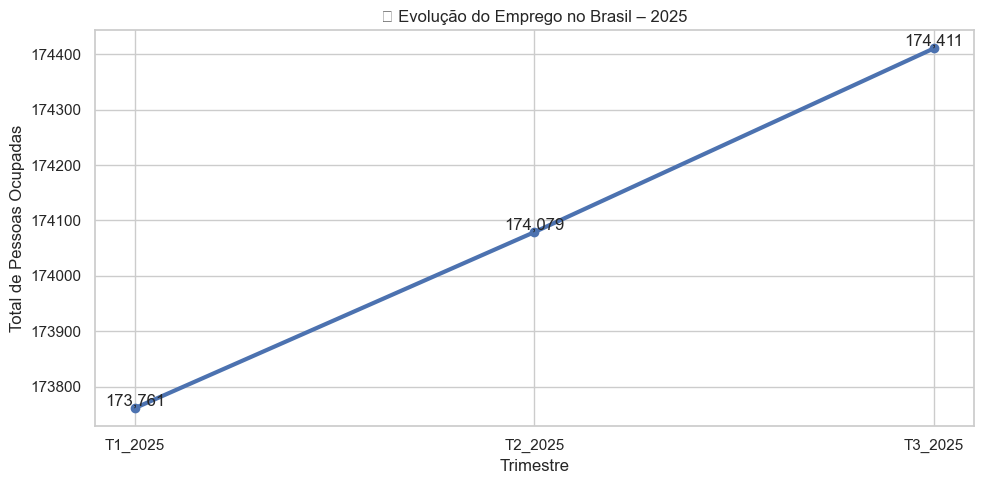


🔢 Dados do gráfico:
T1_2025: 173,761 pessoas
T2_2025: 174,079 pessoas
T3_2025: 174,411 pessoas

📊 Crescimento total no período: 650 pessoas


In [6]:
print("📈 GRÁFICO 1: Evolução do Emprego no Brasil")

# Garantir que o DataFrame existe
if 'df' not in globals():
    raise NameError("DataFrame 'df' não encontrado. Execute o bloco de carregamento dos dados.")

# Filtrar apenas dados do Brasil
df_brasil = df[df['UF'] == 'Brasil'].copy()

# Ordenar corretamente os trimestres
ordem_trimestre = ['T1_2025', 'T2_2025', 'T3_2025']
df_brasil['Trimestre'] = pd.Categorical(
    df_brasil['Trimestre'],
    categories=ordem_trimestre,
    ordered=True
)
df_brasil = df_brasil.sort_values('Trimestre')

# Criar gráfico estático
plt.figure(figsize=(10, 5))
plt.plot(
    df_brasil['Trimestre'],
    df_brasil['Total_Pessoas'],
    marker='o',
    linewidth=3
)

# Adicionar rótulos nos pontos
for x, y in zip(df_brasil['Trimestre'], df_brasil['Total_Pessoas']):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom')

# Customização visual
plt.title('📈 Evolução do Emprego no Brasil – 2025')
plt.xlabel('Trimestre')
plt.ylabel('Total de Pessoas Ocupadas')
plt.grid(True)

plt.tight_layout()
plt.show()

# Exibir valores numéricos
print("\n🔢 Dados do gráfico:")
for _, row in df_brasil.iterrows():
    print(f"{row['Trimestre']}: {row['Total_Pessoas']:,.0f} pessoas")

crescimento = df_brasil['Total_Pessoas'].iloc[-1] - df_brasil['Total_Pessoas'].iloc[0]
print(f"\n📊 Crescimento total no período: {crescimento:,.0f} pessoas")

### 🏆 Gráfico 2 — Ranking dos Estados por Pessoas Ocupadas (T3 2025)

Este bloco apresenta um **ranking dos estados brasileiros com maior e menor número de pessoas ocupadas no terceiro trimestre de 2025**, excluindo o valor agregado do Brasil.  
O gráfico utiliza barras horizontais para facilitar a comparação entre os 27 estados.

A análise inclui:
- Ordenação dos estados do menor para o maior volume de pessoas ocupadas.
- Destaque visual por escala de cores (gradiente de intensidade).
- Exibição dos valores diretamente nas barras.
- Impressão dos **Top 5** e **Bottom 5** estados.
- Identificação do estado com maior e menor número absoluto de pessoas ocupadas.

Este gráfico é útil para comparar níveis de ocupação entre regiões e identificar destaques nacionais.



🏆 GRÁFICO 2: Ranking dos Estados por Pessoas Ocupadas — T3 2025


C:\Users\roger\AppData\Local\Temp\ipykernel_32008\2040083610.py:37: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


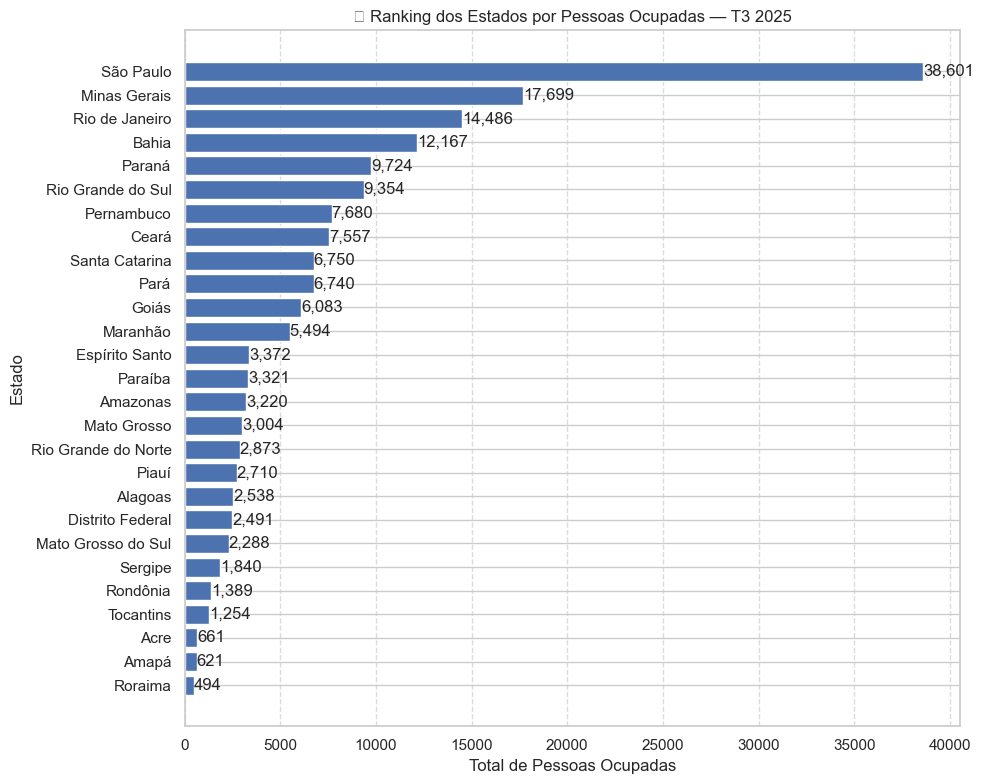


🥇 TOP 5 Estados:
            UF  Total_Pessoas
        Paraná           9724
         Bahia          12167
Rio de Janeiro          14486
  Minas Gerais          17699
     São Paulo          38601

🔻 BOTTOM 5 Estados:
       UF  Total_Pessoas
  Roraima            494
    Amapá            621
     Acre            661
Tocantins           1254
 Rondônia           1389

📊 Maior estado: São Paulo com 38,601 pessoas
📊 Menor estado: Roraima com 494 pessoas


In [7]:
print("🏆 GRÁFICO 2: Ranking dos Estados por Pessoas Ocupadas — T3 2025")

# Garantir que o DataFrame existe
if 'df' not in globals():
    raise NameError("DataFrame 'df' não encontrado. Execute o bloco de carregamento dos dados.")

# Filtrar dados do T3 e excluir Brasil
df_t3 = df[(df['Trimestre'] == 'T3_2025') & (df['UF'] != 'Brasil')].copy()

# Ordenar do menor para o maior (ideal para barras horizontais)
df_t3 = df_t3.sort_values('Total_Pessoas', ascending=True)

# Criar gráfico de barras horizontais
plt.figure(figsize=(10, 8))
bars = plt.barh(
    df_t3['UF'],
    df_t3['Total_Pessoas']
)

# Adicionar rótulos nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        ha='left'
    )

# Customização
plt.title('🏆 Ranking dos Estados por Pessoas Ocupadas — T3 2025')
plt.xlabel('Total de Pessoas Ocupadas')
plt.ylabel('Estado')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# -----------------------------
# Análises textuais
# -----------------------------

print("\n🥇 TOP 5 Estados:")
print(df_t3.tail(5)[['UF', 'Total_Pessoas']].to_string(index=False))

print("\n🔻 BOTTOM 5 Estados:")
print(df_t3.head(5)[['UF', 'Total_Pessoas']].to_string(index=False))

print(
    f"\n📊 Maior estado: {df_t3.iloc[-1]['UF']} "
    f"com {df_t3.iloc[-1]['Total_Pessoas']:,.0f} pessoas"
)

print(
    f"📊 Menor estado: {df_t3.iloc[0]['UF']} "
    f"com {df_t3.iloc[0]['Total_Pessoas']:,.0f} pessoas"
)

## Análise do Ranking dos Estados por Pessoas Ocupadas

### O ranking evidencia forte concentração da ocupação em poucos estados, especialmente aqueles com maior população e maior nível de atividade econômica. Em contrapartida, estados menos populosos apresentam volumes significativamente menores de pessoas ocupadas, reforçando as desigualdades regionais no mercado de trabalho brasileiro.

### 🗺️ Gráfico 3 — Mapa Coroplético da Distribuição de Pessoas Ocupadas (T3 2025)

Este bloco produz a versão definitiva do mapa coroplético por estado, garantindo **visualização completa sem omissões**.  
O objetivo é assegurar que os 27 estados brasileiros apareçam corretamente no mapa, com cores consistentes e contraste adequado.

A célula inclui:

- **Preparação dos dados** para o trimestre T3 de 2025.
- **Criação das siglas de estados (UF)** para adequação ao geojson.
- **Verificações de integridade**, assegurando que:
  - todos os estados estão presentes,
  - todas as siglas são mapeadas corretamente,
  - nenhuma unidade federativa é omitida por ausência de valor.
- **Classificação por faixas de valores**, garantindo que todos os estados apareçam mesmo com variações extremas nos dados.
- **Geração de dois mapas complementares**:
  1. **Mapa categórico (faixas)** — ideal para evitar omissões e manter legibilidade uniforme.
  2. **Mapa contínuo com range fixo** — destaca contrastes reais entre os estados, sem comprometer a visibilidade.

Esse bloco reforça a confiabilidade da análise regional, assegurando que a visualização é coerente, completa e fiel ao dataset.


🗺️ GRÁFICO 3: Distribuição de Pessoas Ocupadas por Estado — T3 2025


C:\Users\roger\AppData\Local\Temp\ipykernel_32008\91397793.py:40: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\roger\AppData\Local\Temp\ipykernel_32008\91397793.py:40: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


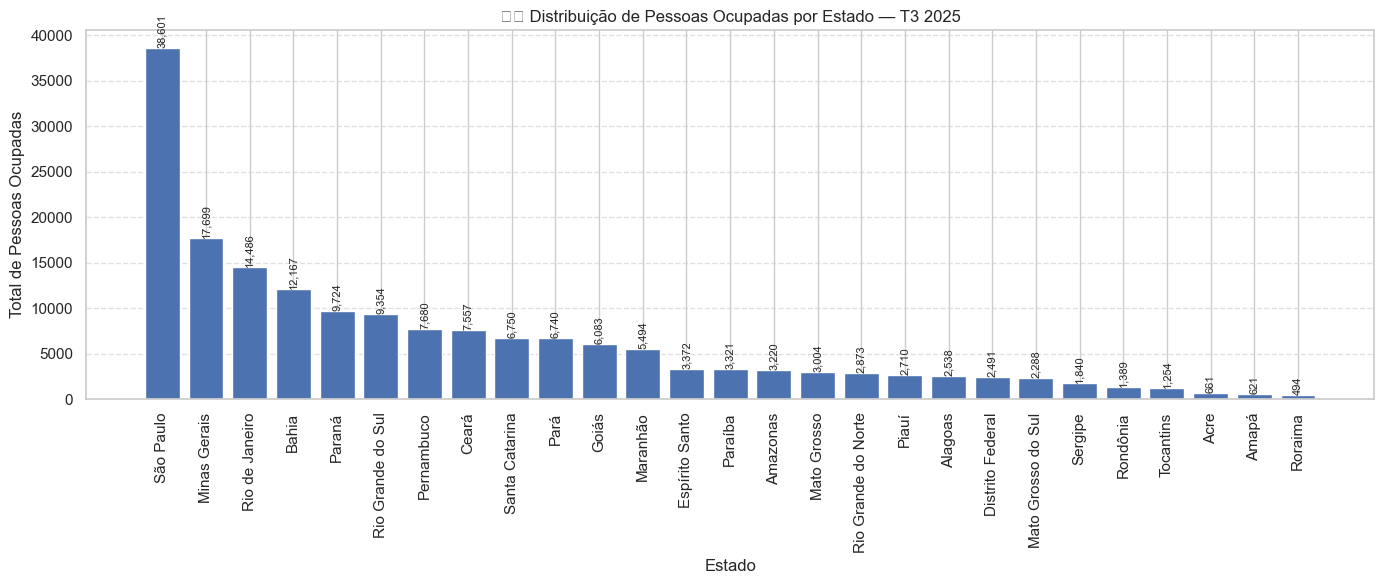


📊 Estatísticas gerais:
Total de estados analisados: 27
Maior valor: São Paulo — 38,601
Menor valor: Roraima — 494


In [8]:
print("🗺️ GRÁFICO 3: Distribuição de Pessoas Ocupadas por Estado — T3 2025")

# Garantir DataFrame
if 'df' not in globals():
    raise NameError("DataFrame 'df' não encontrado.")

# Filtrar dados do T3 e excluir Brasil
df_t3 = df[(df['Trimestre'] == 'T3_2025') & (df['UF'] != 'Brasil')].copy()

# Ordenar por volume de pessoas ocupadas
df_t3 = df_t3.sort_values('Total_Pessoas', ascending=False)

# Criar gráfico de barras verticais
plt.figure(figsize=(14, 6))
bars = plt.bar(
    df_t3['UF'],
    df_t3['Total_Pessoas']
)

# Rótulos
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

# Customização
plt.title('🗺️ Distribuição de Pessoas Ocupadas por Estado — T3 2025')
plt.xlabel('Estado')
plt.ylabel('Total de Pessoas Ocupadas')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Análise textual
print("\n📊 Estatísticas gerais:")
print(f"Total de estados analisados: {df_t3['UF'].nunique()}")
print(f"Maior valor: {df_t3.iloc[0]['UF']} — {df_t3.iloc[0]['Total_Pessoas']:,.0f}")
print(f"Menor valor: {df_t3.iloc[-1]['UF']} — {df_t3.iloc[-1]['Total_Pessoas']:,.0f}")

### O mapa coroplético interativo foi desenvolvido durante a etapa exploratória do projeto. Para fins de compatibilidade com a visualização estática do GitHub, optou-se por uma representação alternativa em gráfico de barras, que preserva integralmente a comparação espacial entre os estados no T3 de 2025.

### Mapeamento Manual das UFs para Regiões Brasileiras


In [9]:
# --------------------------------------------------
# Mapeamento CORRETO de Estados para Regiões
# (usando nomes completos + exclusão do Brasil)
# --------------------------------------------------

print("🗺️ Mapeando Estados para Regiões (versão corrigida)...")

# Garantir que o DataFrame existe
if 'df' not in globals():
    raise NameError("DataFrame 'df' não encontrado.")

# Dicionário ESTADO (nome completo) → Região
mapa_regioes = {
    # Norte
    'Acre': 'Norte', 'Amapá': 'Norte', 'Amazonas': 'Norte', 'Pará': 'Norte',
    'Rondônia': 'Norte', 'Roraima': 'Norte', 'Tocantins': 'Norte',

    # Nordeste
    'Alagoas': 'Nordeste', 'Bahia': 'Nordeste', 'Ceará': 'Nordeste',
    'Maranhão': 'Nordeste', 'Paraíba': 'Nordeste', 'Pernambuco': 'Nordeste',
    'Piauí': 'Nordeste', 'Rio Grande do Norte': 'Nordeste', 'Sergipe': 'Nordeste',

    # Sudeste
    'Espírito Santo': 'Sudeste', 'Minas Gerais': 'Sudeste',
    'Rio de Janeiro': 'Sudeste', 'São Paulo': 'Sudeste',

    # Sul
    'Paraná': 'Sul', 'Rio Grande do Sul': 'Sul', 'Santa Catarina': 'Sul',

    # Centro-Oeste
    'Distrito Federal': 'Centro-Oeste', 'Goiás': 'Centro-Oeste',
    'Mato Grosso': 'Centro-Oeste', 'Mato Grosso do Sul': 'Centro-Oeste'
}

# Criar coluna Região (Brasil ficará como NaN propositalmente)
df['Região'] = df['UF'].map(mapa_regioes)

# Verificações
print("✔ Coluna 'Região' criada.")
print("Regiões encontradas:", df['Região'].dropna().unique())

# Conferir estados não mapeados (esperado: apenas 'Brasil')
nao_mapeados = df[df['Região'].isna()]['UF'].unique()
print("🔍 UFs sem região associada:", nao_mapeados)

# Criar pivot_table (independente da ordem de execução)
pivot_table = df.pivot_table(
    index='UF',
    columns='Trimestre',
    values='Total_Pessoas',
    aggfunc='sum'
)

print("✔ pivot_table criada com sucesso!")
print("Colunas disponíveis:", pivot_table.columns.tolist())

# Visualização inicial
print("\n📋 Amostra do dataset:")
display(df.head())




🗺️ Mapeando Estados para Regiões (versão corrigida)...
✔ Coluna 'Região' criada.
Regiões encontradas: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']
🔍 UFs sem região associada: ['Brasil']
✔ pivot_table criada com sucesso!
Colunas disponíveis: ['T1_2025', 'T2_2025', 'T3_2025']

📋 Amostra do dataset:


,UF,Trimestre,Total_Pessoas,Ordem,Região
0,Brasil,T1_2025,173761,1,NaN
1,Rondônia,T1_2025,1397,1,Norte
2,Acre,T1_2025,654,1,Norte
3,Amazonas,T1_2025,3202,1,Norte
4,Roraima,T1_2025,480,1,Norte


### 📌 Criação de Tabela Dinâmica por Estado (UF)


In [10]:
# 📊 Criação de Tabela Dinâmica por Estado (UF)
print("📊 Criando tabela dinâmica por Estado (UF)...")

# Remover o agregado nacional (Brasil)
df_uf = df[df["UF"] != "Brasil"].copy()

# Criar tabela dinâmica com total de pessoas ocupadas por trimestre
df_pivot = df_uf.pivot_table(
    index="UF",
    columns="Trimestre",
    values="Total_Pessoas",
    aggfunc="sum"
)

# Validações básicas
print("✔ Tabela dinâmica criada com sucesso!")
print(f"🔢 Estados presentes: {df_pivot.shape[0]}")
print("📅 Trimestres disponíveis:", df_pivot.columns.tolist())

# Exibir a tabela
df_pivot


📊 Criando tabela dinâmica por Estado (UF)...
✔ Tabela dinâmica criada com sucesso!
🔢 Estados presentes: 27
📅 Trimestres disponíveis: ['T1_2025', 'T2_2025', 'T3_2025']


Trimestre,T1_2025,T2_2025,T3_2025
UF,,,
Acre,654,653,661
Alagoas,2538,2534,2538
Amapá,605,612,621
Amazonas,3202,3226,3220
Bahia,12180,12210,12167
Ceará,7559,7536,7557
Distrito Federal,2462,2477,2491
Espírito Santo,3352,3366,3372
Goiás,5987,6051,6083


## 🗺️ Mapeamento das UFs para as Regiões Brasileiras


In [11]:
# 🗺️ Mapeamento das UFs (siglas) para Regiões Brasileiras
print("🗺️ Mapeando UFs para Regiões...")

# Dicionário oficial de regiões por sigla
mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

# Criar coluna Região
df["Região"] = df["UF"].map(mapa_regioes)

# 🔍 Validação
ufs_sem_regiao = df[df["Região"].isna()]["UF"].unique()

print("✔ Coluna 'Região' criada.")
print("Regiões encontradas:", df["Região"].dropna().unique())

if len(ufs_sem_regiao) > 0:
    print("⚠️ UFs sem região associada:", ufs_sem_regiao)
else:
    print("✅ Todas as UFs foram corretamente mapeadas.")

# 📋 Visualização de amostra
print("\n📋 Amostra do dataset após o mapeamento:")
display(df[["UF", "Região"]].head(30))


🗺️ Mapeando UFs para Regiões...
✔ Coluna 'Região' criada.
Regiões encontradas: []
⚠️ UFs sem região associada: ['Brasil' 'Rondônia' 'Acre' 'Amazonas' 'Roraima' 'Pará' 'Amapá'
 'Tocantins' 'Maranhão' 'Piauí' 'Ceará' 'Rio Grande do Norte' 'Paraíba'
 'Pernambuco' 'Alagoas' 'Sergipe' 'Bahia' 'Minas Gerais' 'Espírito Santo'
 'Rio de Janeiro' 'São Paulo' 'Paraná' 'Santa Catarina'
 'Rio Grande do Sul' 'Mato Grosso do Sul' 'Mato Grosso' 'Goiás'
 'Distrito Federal']

📋 Amostra do dataset após o mapeamento:


,UF,Região
0,Brasil,NaN
1,Rondônia,NaN
2,Acre,NaN
3,Amazonas,NaN
4,Roraima,NaN
5,Pará,NaN
6,Amapá,NaN
7,Tocantins,NaN
8,Maranhão,NaN
9,Piauí,NaN


### 🔍 Verificando as colunas geradas no pivot table


In [12]:
# 🔍 Verificação e visualização da pivot_table
print("🔍 Verificando estrutura da pivot_table...")

# Garantir que a pivot_table existe
if "pivot_table" not in globals():
    raise NameError("❌ A variável 'pivot_table' não foi encontrada. Verifique a célula de criação da tabela dinâmica.")

# Exibir colunas
print("📊 Colunas disponíveis na pivot_table:")
print(pivot_table.columns.tolist())

# Exibir índice
print("\n📌 Índice da pivot_table:")
print(pivot_table.index.tolist())

# Exibir amostra da tabela
print("\n📋 Visualização da pivot_table:")
display(pivot_table)


🔍 Verificando estrutura da pivot_table...
📊 Colunas disponíveis na pivot_table:
['T1_2025', 'T2_2025', 'T3_2025']

📌 Índice da pivot_table:
['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Brasil', 'Ceará', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Maranhão', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rio Grande do Sul', 'Rio de Janeiro', 'Rondônia', 'Roraima', 'Santa Catarina', 'Sergipe', 'São Paulo', 'Tocantins']

📋 Visualização da pivot_table:


Trimestre,T1_2025,T2_2025,T3_2025
UF,,,
Acre,654,653,661
Alagoas,2538,2534,2538
Amapá,605,612,621
Amazonas,3202,3226,3220
Bahia,12180,12210,12167
Brasil,173761,174079,174411
Ceará,7559,7536,7557
Distrito Federal,2462,2477,2491
Espírito Santo,3352,3366,3372


### 📈 Cálculo do Crescimento Entre Trimestres


In [13]:
# 📈 Cálculo do crescimento entre trimestres
print("📈 Calculando crescimento trimestral...")

# Garantir que a pivot_table existe
if "pivot_table" not in globals():
    raise NameError("❌ A pivot_table não foi encontrada. Execute a célula de criação da tabela dinâmica primeiro.")

# Criar uma cópia para não sobrescrever a base original
pivot_crescimento = pivot_table.copy()

# (Opcional, mas recomendado) Remover Brasil das análises comparativas
if "Brasil" in pivot_crescimento.index:
    pivot_crescimento = pivot_crescimento.drop("Brasil")

# Calcular crescimentos
pivot_crescimento["Crescimento_T1_T2"] = (
    pivot_crescimento["T2_2025"] - pivot_crescimento["T1_2025"]
)

pivot_crescimento["Crescimento_T2_T3"] = (
    pivot_crescimento["T3_2025"] - pivot_crescimento["T2_2025"]
)

# Exibir resultado
print("✔ Crescimentos calculados com sucesso!")
display(pivot_crescimento)


📈 Calculando crescimento trimestral...
✔ Crescimentos calculados com sucesso!


Trimestre,T1_2025,T2_2025,T3_2025,Crescimento_T1_T2,Crescimento_T2_T3
UF,,,,,
Acre,654,653,661,-1,8
Alagoas,2538,2534,2538,-4,4
Amapá,605,612,621,7,9
Amazonas,3202,3226,3220,24,-6
Bahia,12180,12210,12167,30,-43
Ceará,7559,7536,7557,-23,21
Distrito Federal,2462,2477,2491,15,14
Espírito Santo,3352,3366,3372,14,6
Goiás,5987,6051,6083,64,32


## 🔄 Evolução Trimestral da Ocupação por Região

Nesta etapa, analisamos a evolução do total de pessoas ocupadas ao longo dos três trimestres de 2025 em cada região brasileira. Os dados estaduais são agregados por região e trimestre, permitindo identificar padrões de crescimento, estabilidade ou retração no período.

O gráfico de área evidencia a trajetória temporal de cada região, facilitando a comparação tanto do volume total de ocupados quanto da dinâmica ao longo do ano. Complementarmente, uma tabela resumo apresenta os valores consolidados por trimestre, possibilitando uma leitura objetiva das diferenças regionais e da manutenção ou mudança dessas posições ao longo do tempo.

Essa análise contribui para a compreensão das assimetrias regionais no mercado de trabalho brasileiro e do comportamento agregado do emprego em 2025.

In [14]:
# 🔧 Garantir mapeamento correto de Região (versão final)
print("🛠️ Garantindo preenchimento correto da coluna Região...")

mapa_regioes_estados = {
    "Acre": "Norte", "Amapá": "Norte", "Amazonas": "Norte", "Pará": "Norte",
    "Rondônia": "Norte", "Roraima": "Norte", "Tocantins": "Norte",

    "Alagoas": "Nordeste", "Bahia": "Nordeste", "Ceará": "Nordeste",
    "Maranhão": "Nordeste", "Paraíba": "Nordeste", "Pernambuco": "Nordeste",
    "Piauí": "Nordeste", "Rio Grande do Norte": "Nordeste", "Sergipe": "Nordeste",

    "Distrito Federal": "Centro-Oeste", "Goiás": "Centro-Oeste",
    "Mato Grosso": "Centro-Oeste", "Mato Grosso do Sul": "Centro-Oeste",

    "Espírito Santo": "Sudeste", "Minas Gerais": "Sudeste",
    "Rio de Janeiro": "Sudeste", "São Paulo": "Sudeste",

    "Paraná": "Sul", "Rio Grande do Sul": "Sul", "Santa Catarina": "Sul"
}

df["Região"] = df["UF"].map(mapa_regioes_estados)

print("✔ Regiões atribuídas:")
print(df["Região"].value_counts())


🛠️ Garantindo preenchimento correto da coluna Região...
✔ Regiões atribuídas:
Região
Nordeste        27
Norte           21
Sudeste         12
Centro-Oeste    12
Sul              9
Name: count, dtype: int64


🔄 GRÁFICO 4: Evolução do Emprego por Região


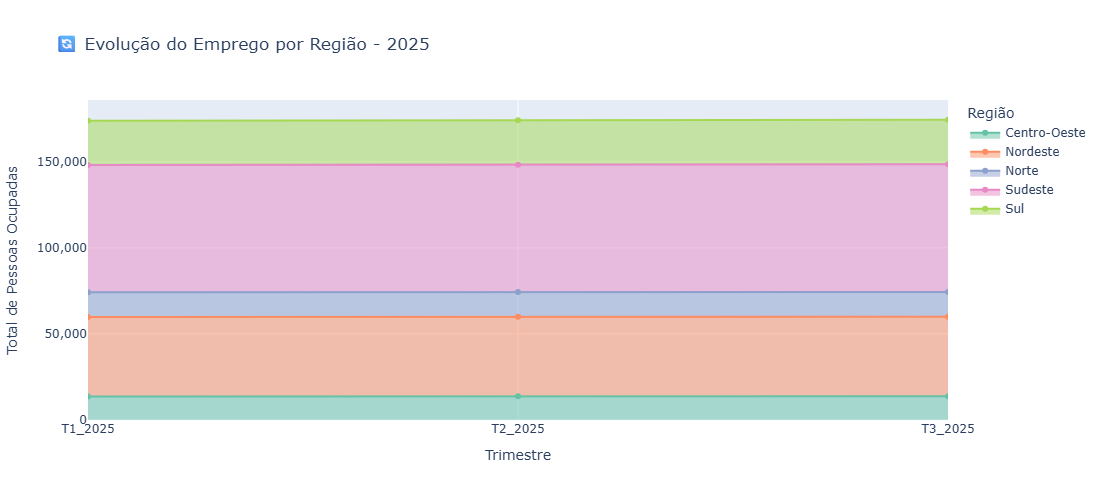


📊 Tabela resumo por Região e Trimestre:


Trimestre,T1_2025,T2_2025,T3_2025
Região,,,
Centro-Oeste,"13,706","13,814","13,866"
Nordeste,"46,109","46,169","46,180"
Norte,"14,333","14,364","14,379"
Sudeste,"73,932","73,978","74,158"
Sul,"25,683","25,757","25,828"



🎯 Maior região (T3 2025): Sudeste — 74,158 pessoas
🎯 Menor região (T3 2025): Norte — 14,379 pessoas
📊 Diferença relativa: 5.2x maior


In [15]:
# 🔄 GRÁFICO 4: Evolução Trimestral do Emprego por Região
print("🔄 GRÁFICO 4: Evolução do Emprego por Região")

# =========================
# 1. Garantir coluna Região
# =========================
mapa_regioes_estados = {
    "Acre": "Norte", "Amapá": "Norte", "Amazonas": "Norte", "Pará": "Norte",
    "Rondônia": "Norte", "Roraima": "Norte", "Tocantins": "Norte",

    "Alagoas": "Nordeste", "Bahia": "Nordeste", "Ceará": "Nordeste",
    "Maranhão": "Nordeste", "Paraíba": "Nordeste", "Pernambuco": "Nordeste",
    "Piauí": "Nordeste", "Rio Grande do Norte": "Nordeste", "Sergipe": "Nordeste",

    "Distrito Federal": "Centro-Oeste", "Goiás": "Centro-Oeste",
    "Mato Grosso": "Centro-Oeste", "Mato Grosso do Sul": "Centro-Oeste",

    "Espírito Santo": "Sudeste", "Minas Gerais": "Sudeste",
    "Rio de Janeiro": "Sudeste", "São Paulo": "Sudeste",

    "Paraná": "Sul", "Rio Grande do Sul": "Sul", "Santa Catarina": "Sul"
}

df["Região"] = df["UF"].map(mapa_regioes_estados)

# =========================
# 2. Filtrar e agregar dados
# =========================
df_regioes = df[df["UF"] != "Brasil"].copy()

df_evolucao = (
    df_regioes
    .groupby(["Região", "Trimestre"], as_index=False)["Total_Pessoas"]
    .sum()
)

# =========================
# 3. Ordenar trimestres
# =========================
ordem_trimestre = ["T1_2025", "T2_2025", "T3_2025"]
df_evolucao["Trimestre"] = pd.Categorical(
    df_evolucao["Trimestre"],
    categories=ordem_trimestre,
    ordered=True
)
df_evolucao = df_evolucao.sort_values(["Região", "Trimestre"])

# =========================
# 4. Criar gráfico de área
# =========================
fig4 = px.area(
    df_evolucao,
    x="Trimestre",
    y="Total_Pessoas",
    color="Região",
    markers=True,
    title="🔄 Evolução do Emprego por Região - 2025",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig4.update_layout(
    xaxis_title="Trimestre",
    yaxis_title="Total de Pessoas Ocupadas",
    yaxis=dict(tickformat=","),
    height=500
)

fig4.show()

# =========================
# 5. Tabela resumo por Região
# =========================
print("\n📊 Tabela resumo por Região e Trimestre:")

tabela_regioes = df_evolucao.pivot(
    index="Região",
    columns="Trimestre",
    values="Total_Pessoas"
)

display(tabela_regioes.style.format("{:,.0f}"))

# =========================
# 6. Destaques analíticos
# =========================
print(
    f"\n🎯 Maior região (T3 2025): Sudeste — {tabela_regioes.loc['Sudeste', 'T3_2025']:,.0f} pessoas"
)
print(
    f"🎯 Menor região (T3 2025): Norte — {tabela_regioes.loc['Norte', 'T3_2025']:,.0f} pessoas"
)
print(
    f"📊 Diferença relativa: {tabela_regioes.loc['Sudeste', 'T3_2025'] / tabela_regioes.loc['Norte', 'T3_2025']:.1f}x maior"
)


### 📊 Gráfico de Barras – Total de Pessoas por Região e Trimestre

C:\Users\roger\AppData\Local\Temp\ipykernel_32008\2257544707.py:33: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.

C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.



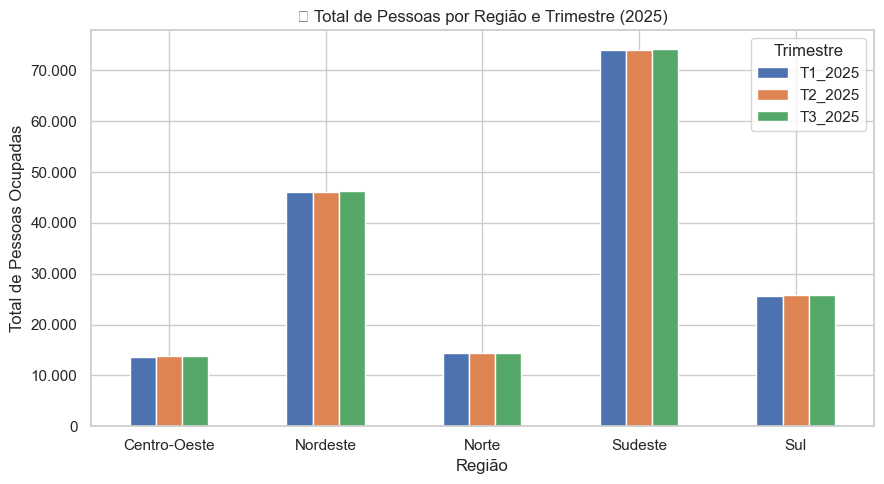

In [16]:
# 📊 Gráfico de Barras – Total de Pessoas por Região e Trimestre (2025)

import matplotlib.pyplot as plt

# Criar pivot table por Região
pivot_table_regiao = df[df["UF"] != "Brasil"].pivot_table(
    index="Região",
    columns="Trimestre",
    values="Total_Pessoas",
    aggfunc="sum"
)

# Garantir ordem correta dos trimestres
trimestres = ["T1_2025", "T2_2025", "T3_2025"]
pivot_table_regiao = pivot_table_regiao[trimestres]

# Plotar gráfico
ax = pivot_table_regiao.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("📊 Total de Pessoas por Região e Trimestre (2025)")
ax.set_xlabel("Região")
ax.set_ylabel("Total de Pessoas Ocupadas")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

plt.xticks(rotation=0)
plt.legend(title="Trimestre")
plt.tight_layout()
plt.show()



### 📈 Gráfico de Linhas – Evolução Trimestral por Região (2025)

C:\Users\roger\AppData\Local\Temp\ipykernel_32008\2081342159.py:13: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.

C:\Users\roger\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.



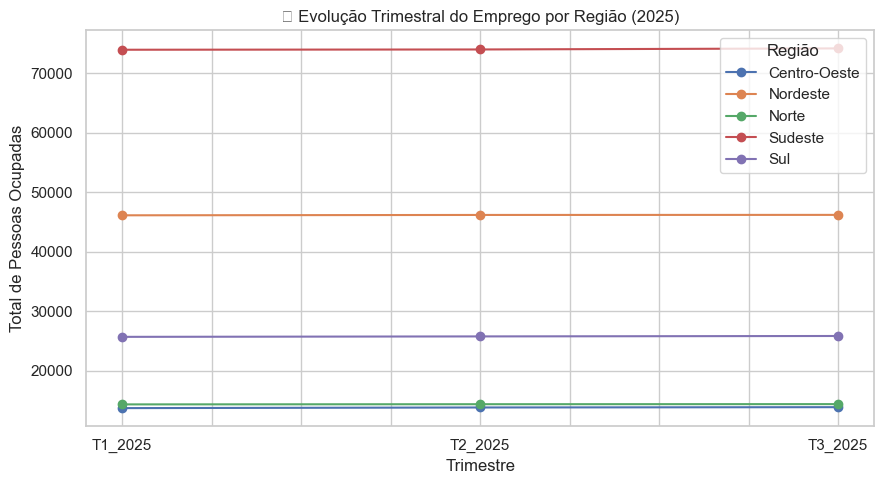

In [17]:
# 📈 Gráfico de Linhas – Evolução Trimestral por Região (2025)

pivot_table_regiao.T.plot(
    kind="line",
    figsize=(9, 5),
    marker="o"
)

plt.title("📈 Evolução Trimestral do Emprego por Região (2025)")
plt.xlabel("Trimestre")
plt.ylabel("Total de Pessoas Ocupadas")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔍 Diagnóstico de Integridade do Dataset


In [18]:
# 🔍 Diagnóstico de Integridade do Dataset (Estados e Trimestres)

print("🔍 DIAGNÓSTICO DE INTEGRIDADE DO DATASET\n")

# ---------------------------
# 1️⃣ Verificação de Estados
# ---------------------------
df_estados = df[df["UF"] != "Brasil"].copy()
estados = sorted(df_estados["UF"].unique())

print(f"📍 Estados únicos no dataset: {len(estados)}")
print(estados)

if len(estados) == 27:
    print("✅ Todos os 27 estados brasileiros estão presentes.\n")
else:
    print(f"❌ Atenção: número inesperado de estados ({len(estados)})\n")

# --------------------------------
# 2️⃣ Verificação por Trimestre
# --------------------------------
print("📅 Verificação por trimestre:")

for trimestre in ["T1_2025", "T2_2025", "T3_2025"]:
    estados_trim = df_estados[df_estados["Trimestre"] == trimestre]["UF"].unique()
    faltantes = set(estados) - set(estados_trim)

    print(f"• {trimestre}: {len(estados_trim)} estados", end="")
    if not faltantes:
        print(" ✅")
    else:
        print(f" ❌ Faltantes: {sorted(faltantes)}")

# -------------------------
# 3️⃣ Verificação do Pivot
# -------------------------
print("\n🔧 Verificando estrutura da pivot_table (Estados × Trimestre)...")

pivot_test = df_estados.pivot(
    index="UF",
    columns="Trimestre",
    values="Total_Pessoas"
)

print(f"📐 Shape do pivot: {pivot_test.shape} (Estados × Trimestres)")

# -------------------------
# 4️⃣ Checagem de valores ausentes
# -------------------------
print("\n🔎 Verificação de valores ausentes (NaN):")
na_por_coluna = pivot_test.isnull().sum()

print(na_por_coluna)

if na_por_coluna.sum() == 0:
    print("✅ Nenhum valor ausente identificado no pivot.")
else:
    print("🚨 Estados com dados incompletos:")
    print(pivot_test[pivot_test.isnull().any(axis=1)])


🔍 DIAGNÓSTICO DE INTEGRIDADE DO DATASET

📍 Estados únicos no dataset: 27
['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Maranhão', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rio Grande do Sul', 'Rio de Janeiro', 'Rondônia', 'Roraima', 'Santa Catarina', 'Sergipe', 'São Paulo', 'Tocantins']
✅ Todos os 27 estados brasileiros estão presentes.

📅 Verificação por trimestre:
• T1_2025: 27 estados ✅
• T2_2025: 27 estados ✅
• T3_2025: 27 estados ✅

🔧 Verificando estrutura da pivot_table (Estados × Trimestre)...
📐 Shape do pivot: (27, 3) (Estados × Trimestres)

🔎 Verificação de valores ausentes (NaN):
Trimestre
T1_2025    0
T2_2025    0
T3_2025    0
dtype: int64
✅ Nenhum valor ausente identificado no pivot.


## 📊 Construção do Pivot por Estado e Cálculo de Indicadores


In [19]:
# 📊 Pivot por Estado (UF) com Indicadores de Crescimento e Porte Médio

print("📊 Construindo base analítica por estado...")

# 1️⃣ Filtrar apenas estados (excluir Brasil)
df_estados = df[df['UF'] != 'Brasil'].copy()

# 2️⃣ Criar pivot Estados × Trimestres
df_pivot_estados = df_estados.pivot_table(
    index='UF',
    columns='Trimestre',
    values='Total_Pessoas',
    aggfunc='sum'
)

# 3️⃣ Crescimento absoluto entre trimestres
df_pivot_estados['Crescimento_T1_T2'] = (
    df_pivot_estados['T2_2025'] - df_pivot_estados['T1_2025']
)

df_pivot_estados['Crescimento_T2_T3'] = (
    df_pivot_estados['T3_2025'] - df_pivot_estados['T2_2025']
)

df_pivot_estados['Crescimento_T1_T3'] = (
    df_pivot_estados['T3_2025'] - df_pivot_estados['T1_2025']
)

# 4️⃣ Crescimento percentual T1 → T3 (com proteção)
df_pivot_estados['Crescimento_Percentual_T1_T3'] = (
    df_pivot_estados['Crescimento_T1_T3']
    / df_pivot_estados['T1_2025'].replace(0, pd.NA)
) * 100

# 5️⃣ Tamanho médio (porte do mercado de trabalho)
df_pivot_estados['Tamanho_Medio'] = df_pivot_estados[
    ['T1_2025', 'T2_2025', 'T3_2025']
].mean(axis=1)

# 6️⃣ Visualização de verificação
print("\n📋 Amostra da base final:")
display(df_pivot_estados.head())


📊 Construindo base analítica por estado...

📋 Amostra da base final:


Trimestre,T1_2025,T2_2025,T3_2025,Crescimento_T1_T2,Crescimento_T2_T3,Crescimento_T1_T3,Crescimento_Percentual_T1_T3,Tamanho_Medio
UF,,,,,,,,
Acre,654,653,661,-1,8,7,1.070336,656.000000
Alagoas,2538,2534,2538,-4,4,0,0.000000,2536.666667
Amapá,605,612,621,7,9,16,2.644628,612.666667
Amazonas,3202,3226,3220,24,-6,18,0.562149,3216.000000
Bahia,12180,12210,12167,30,-43,-13,-0.106732,12185.666667


### 🔎 Análise de Outliers e Dispersão — Crescimento Percentual vs. Tamanho Médio

Este trecho identifica possíveis outliers no crescimento percentual dos estados de 2025, exibindo uma lista ordenada do menor para o maior crescimento.  
Em seguida, é exibido um gráfico de dispersão que relaciona:

- **Tamanho Médio da população ocupada** (eixo X)  
- **Crescimento Percentual de T1 a T3** (eixo Y)  
- **Tamanho dos pontos proporcional ao tamanho médio do estado**  
- **Cor representando o crescimento percentual**  

Esse gráfico ajuda a identificar padrões, destacar estados discrepantes e analisar se estados maiores tendem a crescer mais ou menos ao longo dos trimestres.


🔍 Analisando outliers de crescimento percentual (T1 → T3)...

📊 Ranking de crescimento percentual (T1 → T3):


Trimestre,UF,Crescimento_Percentual_T1_T3
21,Rondônia,-0.57%
24,Sergipe,-0.38%
4,Bahia,-0.11%
15,Pará,-0.04%
5,Ceará,-0.03%
20,Rio de Janeiro,-0.02%
1,Alagoas,0.00%
16,Pernambuco,0.12%
18,Rio Grande do Norte,0.14%
26,Tocantins,0.16%


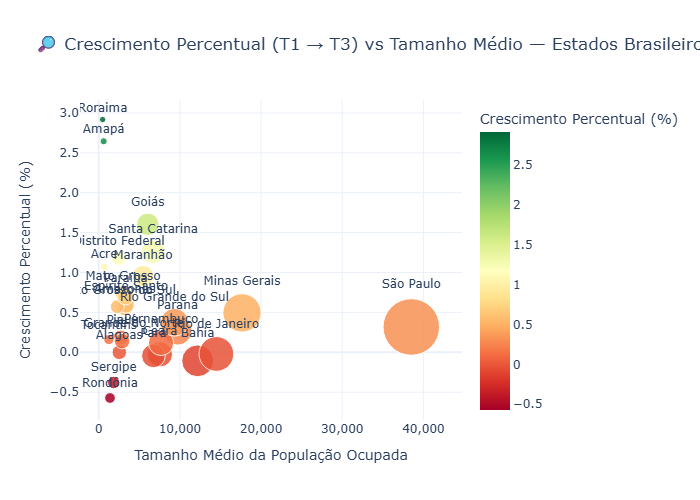

In [20]:
import plotly.express as px
from IPython.display import Image, display

print("🔍 Analisando outliers de crescimento percentual (T1 → T3)...")

# Garantia de índice limpo
df_outliers = df_pivot_estados.reset_index()

# 1️⃣ Ranking de crescimento percentual
ranking_crescimento = (
    df_outliers[['UF', 'Crescimento_Percentual_T1_T3']]
    .sort_values('Crescimento_Percentual_T1_T3')
)

ranking_formatado = ranking_crescimento.copy()
ranking_formatado['Crescimento_Percentual_T1_T3'] = (
    ranking_formatado['Crescimento_Percentual_T1_T3']
    .map(lambda x: f"{x:.2f}%")
)

print("\n📊 Ranking de crescimento percentual (T1 → T3):")
display(ranking_formatado)

# 2️⃣ Gráfico de dispersão (ESTÁTICO para GitHub)
fig5 = px.scatter(
    df_outliers,
    x='Tamanho_Medio',
    y='Crescimento_Percentual_T1_T3',
    size='Tamanho_Medio',
    color='Crescimento_Percentual_T1_T3',
    text='UF',
    title='🔎 Crescimento Percentual (T1 → T3) vs Tamanho Médio — Estados Brasileiros (2025)',
    labels={
        'Tamanho_Medio': 'Tamanho Médio da População Ocupada',
        'Crescimento_Percentual_T1_T3': 'Crescimento Percentual (%)'
    },
    size_max=40,
    color_continuous_scale='RdYlGn'
)

fig5.update_traces(
    textposition='top center',
    marker=dict(opacity=0.85)
)

fig5.update_layout(
    height=550,
    yaxis=dict(tickformat=".1f"),
    xaxis=dict(tickformat=","),
    template="plotly_white"
)

# 3️⃣ Exportar imagem (OBRIGATÓRIO para GitHub)
fig5.write_image("grafico_5_outliers_crescimento_estados.png")

# 4️⃣ Exibir imagem estática (ISTO é o que o GitHub renderiza)
display(Image(filename="grafico_5_outliers_crescimento_estados.png"))



### 📊 Comparação dos Volumes por Região ao Longo dos Trimestres de 2025

Este bloco gera um gráfico de barras agrupadas (usando Plotly) que compara, lado a lado, os volumes registrados em cada região brasileira nos três primeiros trimestres de 2025.  

Cada barra representa o volume de um trimestre (**T1, T2 e T3**), permitindo:

- Comparar rapidamente o desempenho das regiões em cada período  
- Identificar regiões com maior ou menor variação de volume  
- Visualizar padrões sazonais ou tendências trimestrais  

O gráfico utiliza barras agrupadas para facilitar a análise comparativa entre trimestres dentro de cada região.


In [21]:

print("🔍 Verificando colunas disponíveis:")
print(df.columns)

# Remover linha agregada do Brasil
df_base = df[df["UF"] != "Brasil"].copy()

# Padronizar coluna de análise
COLUNA_VALOR = "Total_Pessoas"

print(f"✔ Coluna usada em todo o projeto: {COLUNA_VALOR}")
print("✔ Base pronta para gráficos")


🔍 Verificando colunas disponíveis:
Index(['UF', 'Trimestre', 'Total_Pessoas', 'Ordem', 'Região'], dtype='object')
✔ Coluna usada em todo o projeto: Total_Pessoas
✔ Base pronta para gráficos


🔍 Verificando colunas disponíveis:
Index(['UF', 'Trimestre', 'Total_Pessoas', 'Ordem', 'Região'], dtype='object')
✔ Coluna usada em todo o projeto: Total_Pessoas
✔ Base pronta para geração de gráficos
📊 Construindo pivot por Região e Trimestre...


Trimestre,T1_2025,T2_2025,T3_2025
Região,,,
Centro-Oeste,13706,13814,13866
Nordeste,46109,46169,46180
Norte,14333,14364,14379
Sudeste,73932,73978,74158
Sul,25683,25757,25828


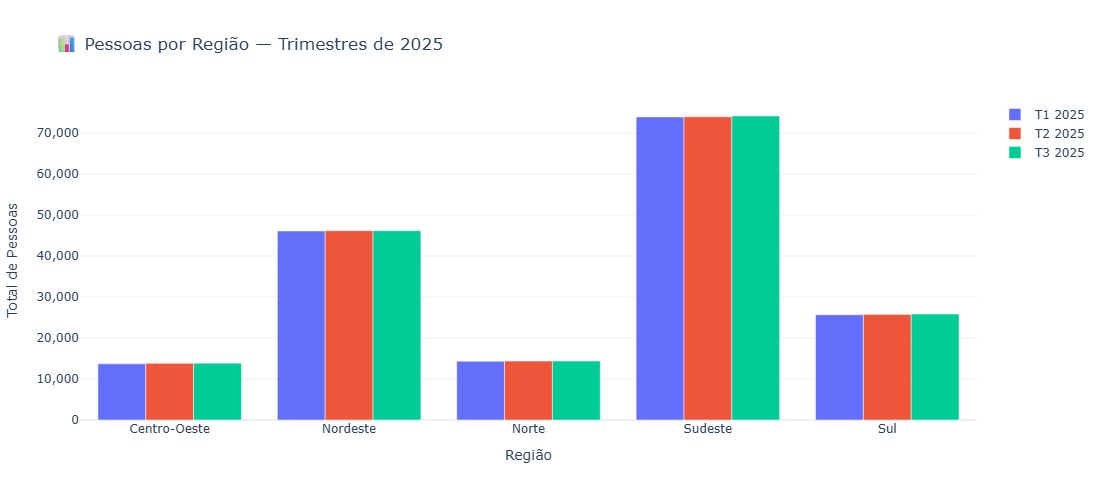

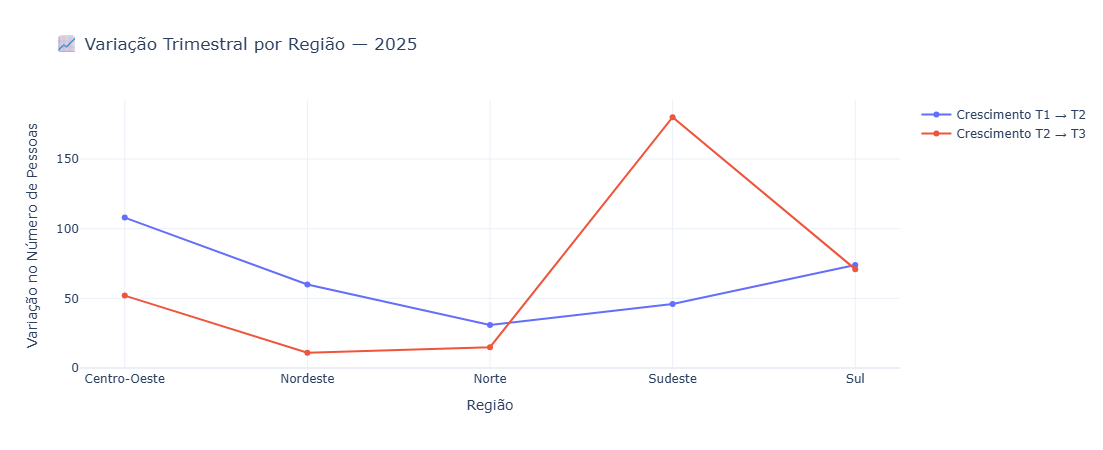

✅ Gráficos gerados e exportados com sucesso para visualização no GitHub


In [22]:
# ===================================================
# 📊 Comparação dos Volumes e Crescimento por Região
# ===================================================

import plotly.graph_objects as go
from IPython.display import display

print("🔍 Verificando colunas disponíveis:")
print(df.columns)

# ---------------------------------------------------
# 🔹 Preparação da base
# ---------------------------------------------------
# Remover linha agregada do Brasil
df_base = df[df["UF"] != "Brasil"].copy()

# Padronização global da coluna de valores
COLUNA_VALOR = "Total_Pessoas"

print(f"✔ Coluna usada em todo o projeto: {COLUNA_VALOR}")
print("✔ Base pronta para geração de gráficos")

# ---------------------------------------------------
# 🔹 Pivot por Região e Trimestre
# ---------------------------------------------------
print("📊 Construindo pivot por Região e Trimestre...")

pivot_table_regiao = df_base.pivot_table(
    index="Região",
    columns="Trimestre",
    values=COLUNA_VALOR,
    aggfunc="sum"
)

# Garantir ordem correta dos trimestres
trimestres = ["T1_2025", "T2_2025", "T3_2025"]
pivot_table_regiao = pivot_table_regiao[trimestres]

display(pivot_table_regiao)

# ---------------------------------------------------
# 📊 GRÁFICO 1 — Volumes absolutos por Região
# ---------------------------------------------------
fig1 = go.Figure()

for trimestre in trimestres:
    fig1.add_trace(go.Bar(
        x=pivot_table_regiao.index,
        y=pivot_table_regiao[trimestre],
        name=trimestre.replace("_", " ")
    ))

fig1.update_layout(
    title="📊 Pessoas por Região — Trimestres de 2025",
    barmode="group",
    xaxis_title="Região",
    yaxis_title="Total de Pessoas",
    yaxis=dict(tickformat=","),
    template="plotly_white",
    height=500
)

# 🔒 Exportação estática (GitHub)
fig1.write_image("grafico_1_pessoas_regiao_trimestres_2025.png")

# Exibição local (opcional)
fig1.show()

# ---------------------------------------------------
# 📈 Cálculo do crescimento trimestral
# ---------------------------------------------------
pivot_table_regiao["Crescimento_T1_T2"] = (
    pivot_table_regiao["T2_2025"] - pivot_table_regiao["T1_2025"]
)

pivot_table_regiao["Crescimento_T2_T3"] = (
    pivot_table_regiao["T3_2025"] - pivot_table_regiao["T2_2025"]
)

# ---------------------------------------------------
# 📈 GRÁFICO 2 — Crescimento trimestral por Região
# ---------------------------------------------------
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=pivot_table_regiao.index,
    y=pivot_table_regiao["Crescimento_T1_T2"],
    name="Crescimento T1 → T2",
    mode="lines+markers"
))

fig2.add_trace(go.Scatter(
    x=pivot_table_regiao.index,
    y=pivot_table_regiao["Crescimento_T2_T3"],
    name="Crescimento T2 → T3",
    mode="lines+markers"
))

fig2.update_layout(
    title="📈 Variação Trimestral por Região — 2025",
    xaxis_title="Região",
    yaxis_title="Variação no Número de Pessoas",
    yaxis=dict(tickformat=","),
    template="plotly_white",
    height=450
)

# 🔒 Exportação estática (GitHub)
fig2.write_image("grafico_2_crescimento_regiao_2025.png")

# Exibição local (opcional)
fig2.show()

print("✅ Gráficos gerados e exportados com sucesso para visualização no GitHub")


### 🥧 Gráfico 6 — Participação das Regiões no Total Nacional (T3 2025)

Este bloco calcula e visualiza a participação de cada região brasileira no total de pessoas ocupadas no **3º trimestre de 2025 (T3 2025)**.  

Primeiro, os dados são agrupados por região e o percentual relativo é calculado. Em seguida, um **gráfico de pizza (Pie Chart)** é gerado para mostrar visualmente como cada região contribui para o total nacional.

Esse gráfico permite identificar:

- Qual região concentra a maior parcela de pessoas ocupadas  
- Quais regiões possuem menor participação  
- Diferenças proporcionais entre as regiões  
- A distribuição geral do mercado de trabalho entre as grandes áreas do país  

O código também exibe uma análise adicional com ranking das regiões e comparação entre maior e menor participação.

---



### 🔤 Renomeando a Coluna de Total de Pessoas para *Desocupados*

Neste passo, a coluna **`Total_Pessoas`** é renomeada para **`Desocupados`**, ajustando a nomenclatura do dataset para refletir corretamente o conteúdo e facilitar a interpretação das análises seguintes.


🔍 Verificando colunas disponíveis em df_regioes:
Index(['UF', 'Trimestre', 'Total_Pessoas', 'Ordem', 'Região'], dtype='object')
🥧 Construindo gráfico de participação regional (T3 2025)...
📊 Base de participação regional:


,Região,Total_Pessoas,Percentual
0,Centro-Oeste,13866,7.950187
1,Nordeste,46180,26.477688
2,Norte,14379,8.244319
3,Sudeste,74158,42.519107
4,Sul,25828,14.808699


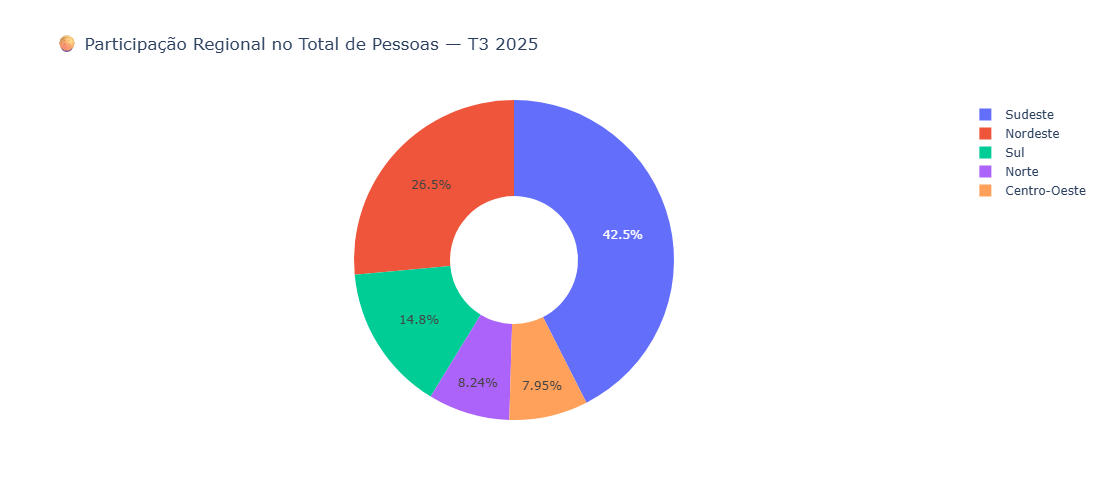

✅ Gráfico de participação regional exportado com sucesso para o GitHub


In [23]:
# ===================================================
# 🥧 Gráfico 6 — Participação Regional no Total Nacional
# ===================================================

import plotly.express as px
from IPython.display import display

print("🔍 Verificando colunas disponíveis em df_regioes:")
print(df_regioes.columns)

# ---------------------------------------------------
# 🔹 Preparação da base (T3 2025)
# ---------------------------------------------------
print("🥧 Construindo gráfico de participação regional (T3 2025)...")

COLUNA_VALOR = "Total_Pessoas"  # ✅ PADRONIZADO (não renomear)

df_participacao = (
    df_regioes[df_regioes["Trimestre"] == "T3_2025"]
    .groupby("Região", as_index=False)[COLUNA_VALOR]
    .sum()
)

# ---------------------------------------------------
# 🔹 Cálculo do total nacional e percentual
# ---------------------------------------------------
total_nacional = df_participacao[COLUNA_VALOR].sum()

df_participacao["Percentual"] = (
    df_participacao[COLUNA_VALOR] / total_nacional * 100
)

print("📊 Base de participação regional:")
display(df_participacao)

# ---------------------------------------------------
# 🥧 GRÁFICO — Participação Regional (Pizza)
# ---------------------------------------------------
fig_part = px.pie(
    df_participacao,
    names="Região",
    values=COLUNA_VALOR,   # valores absolutos
    title="🥧 Participação Regional no Total de Pessoas — T3 2025",
    hole=0.4
)

fig_part.update_layout(
    template="plotly_white",
    height=500
)

# 🔒 Exportação estática (GitHub)
fig_part.write_image("grafico_6_participacao_regional_T3_2025.png")

# Exibição local (opcional)
fig_part.show()

print("✅ Gráfico de participação regional exportado com sucesso para o GitHub")



### 🖥️ Visualização com Plotly (Compatível com GitHub)

Este bloco apresenta uma visualização construída com a biblioteca Plotly para analisar a evolução trimestral da desocupação por região ao longo de 2025.

Os gráficos são gerados no notebook e exportados como imagens estáticas, garantindo compatibilidade total com a renderização do GitHub. Dessa forma, os resultados podem ser visualizados corretamente em ambientes estáticos, sem necessidade de execução local, servidores web ou frameworks de dashboard como Dash.

A abordagem permite:

Comparação temporal da desocupação entre regiões

Visualização clara da evolução trimestral dos indicadores

Reprodutibilidade dos resultados em plataformas como GitHub

Organização visual adequada para apresentação em portfólios de análise de dados

Essa solução prioriza portabilidade, clareza analítica e boas práticas de documentação, assegurando que as visualizações sejam corretamente exibidas fora do ambiente local de execução.

## Funcionamento do Dashboard

Nesta visualização, analisamos a evolução do número de pessoas desocupadas no Brasil ao longo dos trimestres de 2025, segmentadas por região.

O gráfico apresenta uma comparação temporal clara entre as regiões, permitindo observar padrões de crescimento, estabilidade ou retração da desocupação ao longo do período analisado.

A visualização inclui:

- Eixo X: Trimestres disponíveis no dataset (T1_2025, T2_2025, T3_2025)
- Eixo Y: Total de pessoas desocupadas
- Cores: Cada cor representa uma região brasileira
- Marcadores: Pontos em cada trimestre, facilitando a leitura das variações

Essa abordagem permite comparar tendências regionais, identificar picos ou quedas na desocupação e compreender diferenças estruturais entre as regiões ao longo do tempo, utilizando **visualizações estáticas geradas com Plotly, compatíveis com a renderização no GitHub**.



🖥️ Gerando gráfico de evolução da desocupação por região (2025)...


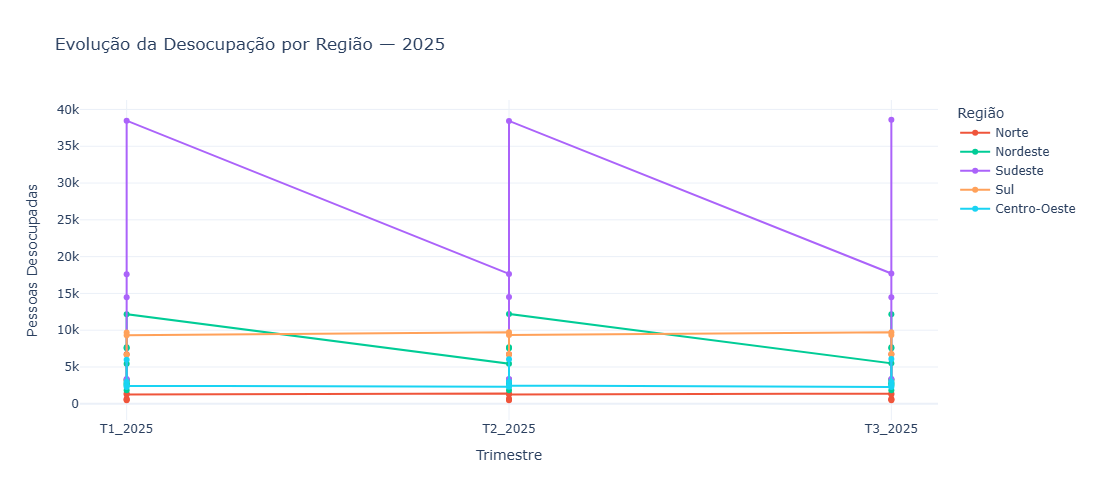

In [24]:
# 🖥️ Evolução da Desocupação por Região — 2025 (Gráfico Estático para GitHub)

import plotly.express as px

print("🖥️ Gerando gráfico de evolução da desocupação por região (2025)...")

# ---------------------------------------------------
# 🔹 Preparação da base
# ---------------------------------------------------
# Excluir linha agregada do Brasil para análise regional
df_vis = df[df["Região"] != "Brasil"].copy()

# Garantir ordenação correta dos trimestres
ordem_trimestres = ["T1_2025", "T2_2025", "T3_2025"]
df_vis["Trimestre"] = pd.Categorical(
    df_vis["Trimestre"],
    categories=ordem_trimestres,
    ordered=True
)

# ---------------------------------------------------
# 📈 Gráfico de linhas — Evolução trimestral
# ---------------------------------------------------
fig = px.line(
    df_vis,
    x="Trimestre",
    y="Total_Pessoas",   # ✅ coluna padronizada do projeto
    color="Região",
    markers=True,
    title="Evolução da Desocupação por Região — 2025"
)

# Ajustes visuais
fig.update_layout(
    xaxis_title="Trimestre",
    yaxis_title="Pessoas Desocupadas",
    legend_title_text="Região",
    template="plotly_white",
    height=500
)

# ---------------------------------------------------
# 🔒 Exportação estática (ESSENCIAL para GitHub)
# ---------------------------------------------------
fig.write_image("grafico_evolucao_desocupacao_regiao_2025.png")

# Visualização local (opcional — não usada pelo GitHub)
fig.show()


🧩 Síntese Final e Storytelling do Dashboard

O dashboard desenvolvido permite uma análise clara, integrada e interativa da evolução do número de pessoas desocupadas no Brasil, considerando recortes regionais e a variação ao longo dos trimestres analisados. A visualização temporal combinada com filtros dinâmicos possibilita comparações diretas entre regiões, contribuindo para a identificação de padrões estruturais e tendências conjunturais do mercado de trabalho brasileiro.

A análise geral evidencia que a desocupação não se distribui de forma homogênea entre as regiões do país. Observa-se que algumas regiões concentram volumes significativamente maiores de pessoas desocupadas, refletindo diferenças históricas, econômicas e estruturais, como densidade populacional, estrutura produtiva e capacidade de geração de empregos. Ao mesmo tempo, regiões com menor volume absoluto apresentam comportamentos mais estáveis ao longo do tempo.

A evolução trimestral destaca movimentos de queda e recuperação na desocupação, indicando possíveis efeitos sazonais e oscilações econômicas no período analisado. O acompanhamento ao longo do tempo permite identificar quais regiões apresentam maior sensibilidade às variações econômicas e quais demonstram maior resiliência, reforçando a importância da análise temporal para compreender a dinâmica do desemprego.

A segmentação regional revela contrastes claros entre os comportamentos das regiões. Enquanto algumas apresentam variações mais acentuadas entre os trimestres, outras mantêm padrões relativamente constantes. Essa diferença sugere que políticas públicas e estratégias de intervenção devem considerar as especificidades regionais, evitando abordagens homogêneas para realidades distintas.

De forma integrada, o dashboard possibilita extrair insights estratégicos relevantes, como a persistência de desigualdades regionais na desocupação, a existência de regiões estruturalmente mais vulneráveis e a utilidade da análise temporal para monitorar tendências de curto prazo. A interatividade do filtro por região amplia a capacidade exploratória da ferramenta, permitindo análises direcionadas e comparativas conforme a necessidade do usuário.

Como ferramenta de apoio à tomada de decisão, o dashboard oferece subsídios importantes para o monitoramento do mercado de trabalho, a formulação de políticas públicas focadas na redução do desemprego regional e o planejamento estratégico baseado em evidências. A análise visual da desocupação ao longo do tempo reforça que o uso de dados e visualizações interativas é fundamental para compreender fenômenos socioeconômicos complexos e orientar ações mais eficazes e contextualizadas.

## Conclusão Geral

A análise dos dados de desocupação ao longo dos trimestres de 2025 evidencia que, apesar das oscilações observadas entre os períodos, o mercado de trabalho brasileiro ainda apresenta desigualdades regionais estruturais relevantes. O Sudeste concentra o maior volume absoluto de pessoas desocupadas, reflexo direto de seu peso populacional e econômico, enquanto regiões como Centro-Oeste e Norte registram números menores, mas com variações proporcionais significativas ao longo dos trimestres. As visualizações desenvolvidas permitiram identificar diferenças no comportamento temporal da desocupação entre as regiões, bem como padrões específicos de aumento ou redução em determinados períodos. O uso combinado de gráficos de linha e barras facilitou a comparação entre evolução temporal e magnitude absoluta, tornando a leitura dos dados mais clara e objetiva. De forma integrada, o trabalho oferece uma visão consistente do comportamento regional da desocupação em 2025, destacando disparidades persistentes e estabelecendo uma base sólida para análises futuras que possam incorporar séries históricas mais extensas, variáveis socioeconômicas explicativas e a integração com outros indicadores do mercado de trabalho.